# AXA-PRISM: Predictive Risk Intelligence & Strategic Mitigation
## Fase 1: Data Understanding dan Data Preparation (CRISP-DM)

---

**Konteks Bisnis:**
AXA menghadapi kenaikan klaim kesehatan sebesar 25,5 persen Year-over-Year. Proyek AXA-PRISM bertujuan membangun Mesin SPK berbasis Hybrid AI (Isolation Forest, K-Means, Regression) yang menggunakan logika *Expected vs Actual Cost* untuk mendeteksi deviasi biaya secara cerdas.

**Tahapan Notebook Ini:**
1. Setup Lingkungan dan Import Library
2. Data Loading dan Eksplorasi Awal (Data Understanding)
3. Data Cleaning (Penanganan Missing Values, Duplikat, Format)
4. Data Merging
5. Outlier Detection dan Treatment
6. Advanced Feature Engineering
7. Encoding dan Scaling
8. Feature Selection
9. Dataset Splitting
10. Ekspor Data Final


---
## Sel 1: Setup Lingkungan dan Import Library

**Tujuan:** Memuat seluruh pustaka Python yang diperlukan untuk proses analisis, visualisasi, preprocessing, dan pemodelan. Setiap kelompok library memiliki peran spesifik dalam pipeline AXA-PRISM.

In [1]:
!pip install pandas
import pandas as pd
import numpy as np

In [2]:
# ============================================================
# SEL 1: SETUP LINGKUNGAN DAN IMPORT LIBRARY
# ============================================================

# Instalasi library tambahan yang mungkin tidak tersedia di Colab
# !pip install scikit-learn pandas numpy matplotlib seaborn scipy -q

# --- Manipulasi Data ---
import pandas as pd
import numpy as np

# --- Visualisasi ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Preprocessing dan Feature Engineering ---
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# --- Model Splitting ---
from sklearn.model_selection import train_test_split

# --- Statistik ---
from scipy import stats

# --- Pengaturan Tampilan ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

import warnings
warnings.filterwarnings('ignore')

print('✅ Seluruh library berhasil dimuat.')
print('   Versi Pandas :', pd.__version__)
print('   Versi NumPy  :', np.__version__)

✅ Seluruh library berhasil dimuat.
   Versi Pandas : 2.3.3
   Versi NumPy  : 2.4.2


---
## Sel 2: Data Loading dan Eksplorasi Awal (Data Understanding)

**Tujuan:** Memuat kedua dataset dan melakukan pemahaman awal terhadap struktur, tipe data, dan kondisi kualitas data. Tahap ini merupakan fondasi dari fase *Data Understanding* dalam CRISP-DM. Kita perlu memahami 'wajah' data sebelum melakukan transformasi apapun.

In [3]:
# ============================================================
# SEL 2A: LOADING DATA
# ============================================================

# Muat dataset polis (data demografis peserta asuransi)
df_polis = pd.read_csv('D:\SEMESTER 6\PBL\Model-Comparison\dataset\Data_Polis.csv')

# Muat dataset klaim (data transaksi klaim kesehatan)
df_klaim = pd.read_csv('D:\SEMESTER 6\PBL\Model-Comparison\dataset\Data_Klaim.csv')

print('=' * 60)
print('RINGKASAN DATASET')
print('=' * 60)
print(f'Data Polis  : {df_polis.shape[0]:,} baris x {df_polis.shape[1]} kolom')
print(f'Data Klaim  : {df_klaim.shape[0]:,} baris x {df_klaim.shape[1]} kolom')
print()

print('--- Sampel Data Polis (5 Baris Pertama) ---')
display(df_polis.head())

print('\n--- Sampel Data Klaim (5 Baris Pertama) ---')
display(df_klaim.head())

RINGKASAN DATASET
Data Polis  : 4,096 baris x 6 kolom
Data Klaim  : 4,627 baris x 13 kolom

--- Sampel Data Polis (5 Baris Pertama) ---


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA



--- Sampel Data Klaim (5 Baris Pertama) ---


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,7/8/2024,5/27/2024,5/27/2024,"28,093,653.00","6,143,947.68",Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,8/6/2024,7/15/2024,7/15/2024,"80,987,278.00","82,309,522.45",Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,10/17/2024,5/16/2024,5/16/2024,"183,047,130.00","192,859,905.00",Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,9/3/2024,7/18/2024,7/18/2024,"191,424,386.00","191,424,385.70",Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,6/6/2024,6/6/2024,"138,936,357.00","138,936,357.00",Singapore


In [4]:
# ============================================================
# SEL 2B: EKSPLORASI STRUKTUR DAN KUALITAS DATA
# ============================================================

def generate_data_report(df, name):
    """
    Fungsi untuk menghasilkan laporan kualitas data secara komprehensif.
    Menampilkan tipe data, jumlah missing values, persentase, dan jumlah nilai unik.
    
    Parameter:
    - df   : DataFrame yang akan dianalisis
    - name : Nama dataset untuk label output
    """
    print(f'\n{'='*60}')
    print(f'  LAPORAN KUALITAS DATA: {name.upper()}')
    print(f'{'='*60}')
    
    report = pd.DataFrame({
        'Tipe Data'      : df.dtypes,
        'Jumlah Non-Null' : df.count(),
        'Missing Values' : df.isnull().sum(),
        'Missing (%)'    : (df.isnull().sum() / len(df) * 100).round(2),
        'Nilai Unik'     : df.nunique()
    })
    display(report)
    
    # Cek duplikat
    dup_count = df.duplicated().sum()
    print(f'\nJumlah Baris Duplikat: {dup_count}')
    return report

generate_data_report(df_polis, 'Data Polis')
generate_data_report(df_klaim, 'Data Klaim')


  LAPORAN KUALITAS DATA: DATA POLIS


,Tipe Data,Jumlah Non-Null,Missing Values,Missing (%),Nilai Unik
Nomor Polis,object,4096,0,0.00,4096
Plan Code,object,4096,0,0.00,3
Gender,object,4096,0,0.00,2
Tanggal Lahir,int64,4096,0,0.00,3718
Tanggal Efektif Polis,int64,4096,0,0.00,1146
Domisili,object,4096,0,0.00,21



Jumlah Baris Duplikat: 0

  LAPORAN KUALITAS DATA: DATA KLAIM


,Tipe Data,Jumlah Non-Null,Missing Values,Missing (%),Nilai Unik
Claim ID,object,4627,0,0.00,4627
Nomor Polis,object,4627,0,0.00,1210
Reimburse/Cashless,object,4627,0,0.00,2
Inpatient/Outpatient,object,4590,37,0.80,4
ICD Diagnosis,object,4621,6,0.13,753
ICD Description,object,4621,6,0.13,945
Status Klaim,object,4627,0,0.00,1
Tanggal Pembayaran Klaim,object,4590,37,0.80,357
Tanggal Pasien Masuk RS,object,4627,0,0.00,564
Tanggal Pasien Keluar RS,object,4627,0,0.00,574



Jumlah Baris Duplikat: 0


,Tipe Data,Jumlah Non-Null,Missing Values,Missing (%),Nilai Unik
Claim ID,object,4627,0,0.00,4627
Nomor Polis,object,4627,0,0.00,1210
Reimburse/Cashless,object,4627,0,0.00,2
Inpatient/Outpatient,object,4590,37,0.80,4
ICD Diagnosis,object,4621,6,0.13,753
ICD Description,object,4621,6,0.13,945
Status Klaim,object,4627,0,0.00,1
Tanggal Pembayaran Klaim,object,4590,37,0.80,357
Tanggal Pasien Masuk RS,object,4627,0,0.00,564
Tanggal Pasien Keluar RS,object,4627,0,0.00,574


--- Statistik Deskriptif: Nominal Biaya Klaim ---


,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi
count,"4,627.00","4,627.00"
mean,"55,028,924.48","59,949,398.03"
std,"131,952,706.29","159,783,760.49"
min,0.00,0.00
25%,"2,274,009.30","2,720,209.50"
50%,"14,467,899.00","15,871,000.00"
75%,"51,072,085.06","54,230,667.53"
max,"2,197,500,000.00","3,892,809,996.00"


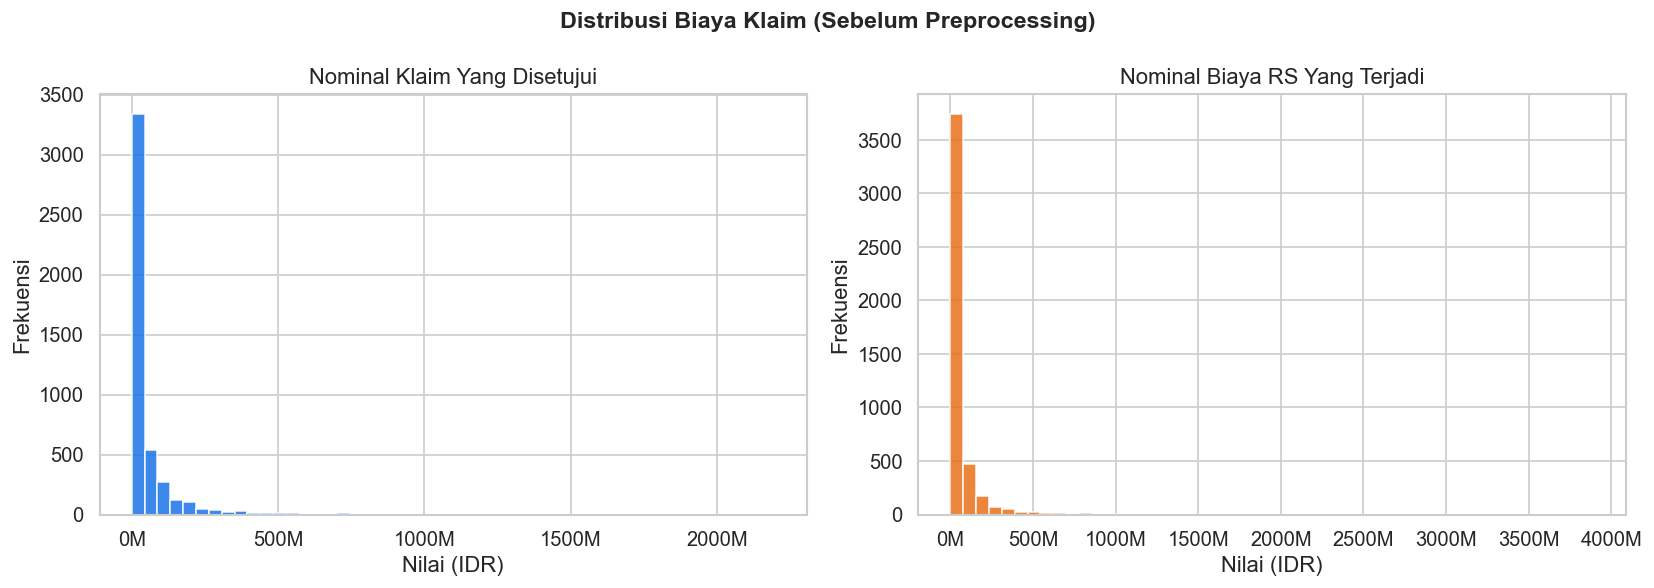

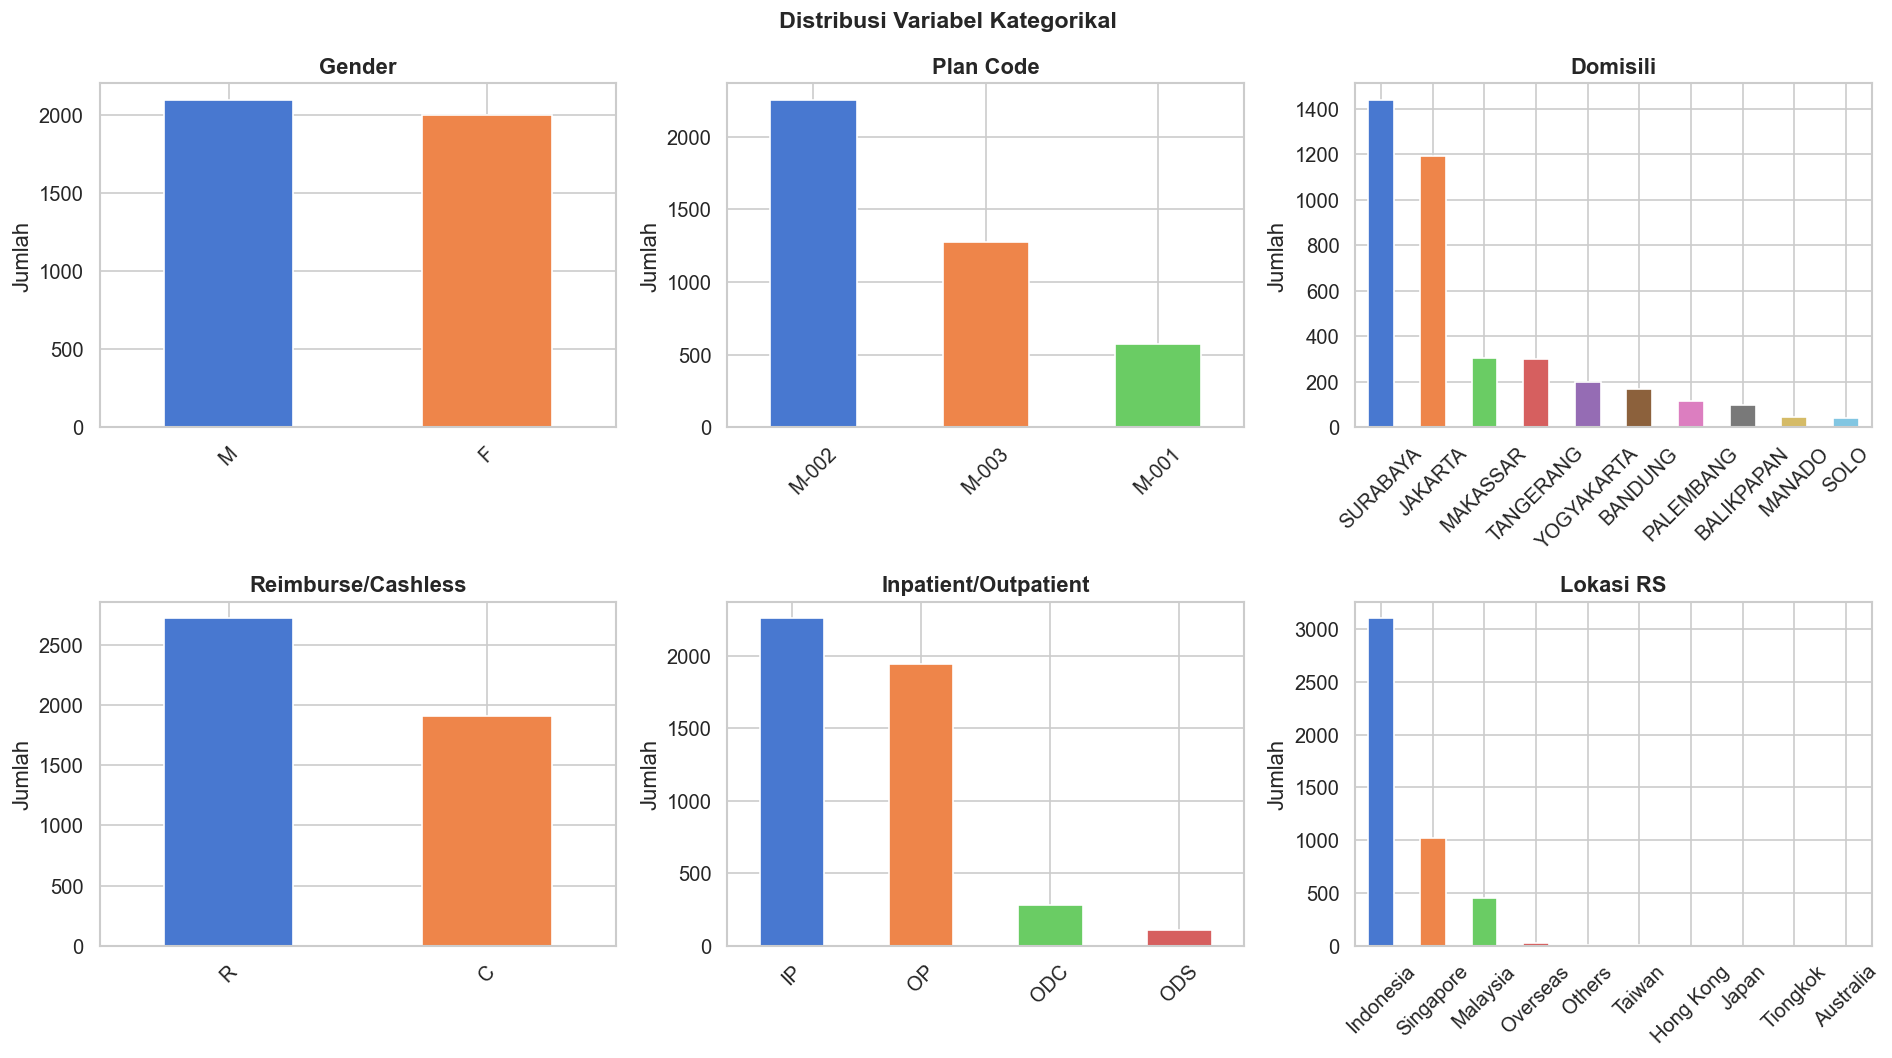


[INSIGHT] Distribusi biaya menunjukkan right-skewed (ekor panjang ke kanan).
[INSIGHT] Ini mengindikasikan adanya potensi outlier pada klaim bernilai sangat tinggi yang perlu diinvestigasi.


In [5]:
# ============================================================
# SEL 2C: STATISTIK DESKRIPTIF DAN VISUALISASI DISTRIBUSI AWAL
# ============================================================

# Statistik deskriptif untuk kolom numerik di Data Klaim
print('--- Statistik Deskriptif: Nominal Biaya Klaim ---')
display(df_klaim[['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']].describe())

# Visualisasi distribusi biaya sebelum preprocessing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Biaya Klaim (Sebelum Preprocessing)', fontsize=14, fontweight='bold')

# Histogram Nominal Klaim Disetujui
axes[0].hist(
    df_klaim['Nominal Klaim Yang Disetujui'].dropna(),
    bins=50, color='#1a73e8', edgecolor='white', alpha=0.85
)
axes[0].set_title('Nominal Klaim Yang Disetujui')
axes[0].set_xlabel('Nilai (IDR)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Histogram Nominal Biaya RS
axes[1].hist(
    df_klaim['Nominal Biaya RS Yang Terjadi'].dropna(),
    bins=50, color='#e8711a', edgecolor='white', alpha=0.85
)
axes[1].set_title('Nominal Biaya RS Yang Terjadi')
axes[1].set_xlabel('Nilai (IDR)')
axes[1].set_ylabel('Frekuensi')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

# Distribusi variabel kategorikal
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold')

cat_cols_polis = [('df_polis', 'Gender'), ('df_polis', 'Plan Code'), ('df_polis', 'Domisili')]
cat_cols_klaim = [('df_klaim', 'Reimburse/Cashless'), ('df_klaim', 'Inpatient/Outpatient'), ('df_klaim', 'Lokasi RS')]

for idx, (dname, col) in enumerate(cat_cols_polis + cat_cols_klaim):
    ax = axes[idx // 3][idx % 3]
    df_src = df_polis if dname == 'df_polis' else df_klaim
    counts = df_src[col].value_counts().head(10)
    counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(counts)), edgecolor='white')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\n[INSIGHT] Distribusi biaya menunjukkan right-skewed (ekor panjang ke kanan).')
print('[INSIGHT] Ini mengindikasikan adanya potensi outlier pada klaim bernilai sangat tinggi yang perlu diinvestigasi.')

---
## Sel 3: Data Cleaning

**Tujuan:** Membersihkan data dari inkonsistensi yang dapat merusak akurasi model. Proses ini meliputi:
- Standarisasi format tanggal dari integer/string ke datetime
- Penanganan missing values menggunakan strategi imputasi yang tepat per kolom
- Penghapusan baris duplikat
- Standarisasi nilai kategorikal

In [6]:
# ============================================================
# SEL 3: DATA CLEANING
# ============================================================

# --- Buat salinan kerja agar data asli tetap terjaga ---
polis = df_polis.copy()
klaim = df_klaim.copy()

# -------------------------------------------------------
# LANGKAH 1: STANDARISASI FORMAT TANGGAL
# Kolom tanggal di df_polis bertipe integer (format YYYYMMDD)
# Kolom tanggal di df_klaim bertipe string (format M/D/YYYY)
# -------------------------------------------------------

print('LANGKAH 1: Konversi Format Tanggal')
print('-' * 40)

# Konversi tanggal integer YYYYMMDD ke datetime
polis['Tanggal Lahir'] = pd.to_datetime(
    polis['Tanggal Lahir'].astype(str), format='%Y%m%d', errors='coerce'
)
polis['Tanggal Efektif Polis'] = pd.to_datetime(
    polis['Tanggal Efektif Polis'].astype(str), format='%Y%m%d', errors='coerce'
)

# Konversi tanggal string M/D/YYYY ke datetime
date_cols_klaim = ['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS']
for col in date_cols_klaim:
    klaim[col] = pd.to_datetime(klaim[col], format='%m/%d/%Y', errors='coerce')

print('Tipe data tanggal setelah konversi:')
print(polis[['Tanggal Lahir', 'Tanggal Efektif Polis']].dtypes)
print(klaim[date_cols_klaim].dtypes)

# -------------------------------------------------------
# LANGKAH 2: PENANGANAN MISSING VALUES
# Strategi imputasi dipilih berdasarkan konteks kolom:
# - Inpatient/Outpatient: mode (nilai terbanyak), karena kategorikal
# - ICD Diagnosis/Description: isi dengan 'UNKNOWN' (tidak bisa diimputasi logis)
# - Tanggal Pembayaran Klaim: isi dengan tanggal masuk RS (proxy terbaik)
# - Lokasi RS: isi dengan mode
# -------------------------------------------------------

print('\nLANGKAH 2: Penanganan Missing Values')
print('-' * 40)

# Imputasi Inpatient/Outpatient dengan mode
mode_ip_op = klaim['Inpatient/Outpatient'].mode()[0]
klaim['Inpatient/Outpatient'].fillna(mode_ip_op, inplace=True)
print(f'Inpatient/Outpatient: diimputasi dengan mode = "{mode_ip_op}"')

# Imputasi ICD dengan placeholder
klaim['ICD Diagnosis'].fillna('Z99', inplace=True)
klaim['ICD Description'].fillna('UNSPECIFIED CONDITION', inplace=True)
print('ICD Diagnosis/Description: diimputasi dengan nilai placeholder "Z99" / "UNSPECIFIED CONDITION"')

# Imputasi tanggal pembayaran klaim dengan tanggal pasien keluar RS
klaim['Tanggal Pembayaran Klaim'].fillna(klaim['Tanggal Pasien Keluar RS'], inplace=True)
print('Tanggal Pembayaran Klaim: diimputasi dengan Tanggal Pasien Keluar RS')

# Imputasi Lokasi RS dengan mode
mode_lokasi = klaim['Lokasi RS'].mode()[0]
klaim['Lokasi RS'].fillna(mode_lokasi, inplace=True)
print(f'Lokasi RS: diimputasi dengan mode = "{mode_lokasi}"')

# -------------------------------------------------------
# LANGKAH 3: HAPUS DUPLIKAT
# -------------------------------------------------------

print('\nLANGKAH 3: Penghapusan Duplikat')
print('-' * 40)

before_polis = len(polis)
before_klaim = len(klaim)
polis.drop_duplicates(inplace=True)
klaim.drop_duplicates(inplace=True)
print(f'Polis: {before_polis - len(polis)} baris duplikat dihapus.')
print(f'Klaim: {before_klaim - len(klaim)} baris duplikat dihapus.')

# -------------------------------------------------------
# LANGKAH 4: STANDARISASI NILAI KATEGORIKAL
# -------------------------------------------------------

print('\nLANGKAH 4: Standarisasi Kategorikal')
print('-' * 40)

# Uppercase dan strip whitespace pada kolom string
str_cols_klaim = ['Reimburse/Cashless', 'Inpatient/Outpatient', 'Lokasi RS', 'Status Klaim']
for col in str_cols_klaim:
    klaim[col] = klaim[col].str.upper().str.strip()

polis['Domisili'] = polis['Domisili'].str.upper().str.strip()
polis['Gender'] = polis['Gender'].str.upper().str.strip()

# Normalisasi Inpatient/Outpatient ke 2 kategori utama: IP dan OP
# ODC (One Day Care) dan ODS (One Day Surgery) dikategorikan sebagai OP
ip_op_mapping = {'IP': 'IP', 'OP': 'OP', 'ODC': 'OP', 'ODS': 'OP'}
klaim['Inpatient/Outpatient'] = klaim['Inpatient/Outpatient'].map(ip_op_mapping).fillna('OP')
print('Inpatient/Outpatient: ODC dan ODS dikonsolidasi ke kategori OP.')

# Verifikasi akhir missing values
total_missing_polis = polis.isnull().sum().sum()
total_missing_klaim = klaim.isnull().sum().sum()
print(f'\nSisa Missing Values - Polis: {total_missing_polis} | Klaim: {total_missing_klaim}')
print('\n✅ Data Cleaning selesai.')

LANGKAH 1: Konversi Format Tanggal
----------------------------------------
Tipe data tanggal setelah konversi:
Tanggal Lahir            datetime64[ns]
Tanggal Efektif Polis    datetime64[ns]
dtype: object
Tanggal Pembayaran Klaim    datetime64[ns]
Tanggal Pasien Masuk RS     datetime64[ns]
Tanggal Pasien Keluar RS    datetime64[ns]
dtype: object

LANGKAH 2: Penanganan Missing Values
----------------------------------------
Inpatient/Outpatient: diimputasi dengan mode = "IP"
ICD Diagnosis/Description: diimputasi dengan nilai placeholder "Z99" / "UNSPECIFIED CONDITION"
Tanggal Pembayaran Klaim: diimputasi dengan Tanggal Pasien Keluar RS
Lokasi RS: diimputasi dengan mode = "Indonesia"

LANGKAH 3: Penghapusan Duplikat
----------------------------------------
Polis: 0 baris duplikat dihapus.
Klaim: 0 baris duplikat dihapus.

LANGKAH 4: Standarisasi Kategorikal
----------------------------------------
Inpatient/Outpatient: ODC dan ODS dikonsolidasi ke kategori OP.

Sisa Missing Values - Pol

---
## Sel 4: Data Merging

**Tujuan:** Menggabungkan dataset polis dan klaim menggunakan `Nomor Polis` sebagai kunci relasi. Ini menghasilkan satu dataset terintegrasi yang memuat informasi demografis peserta beserta histori klaimnya. Kita menggunakan *right merge* agar semua data klaim tetap tersimpan, bahkan jika ada nomor polis yang tidak terdapat di data polis (anomali potensial).

In [7]:
# ============================================================
# SEL 4: DATA MERGING
# ============================================================

# Merge dengan LEFT JOIN: semua klaim dipertahankan, data polis dilampirkan
# Klaim tanpa data polis akan memiliki NaN pada kolom polis (perlu investigasi)
df = pd.merge(
    klaim,
    polis,
    on='Nomor Polis',
    how='left',
    suffixes=('_klaim', '_polis')
)

print('Hasil Merge:')
print(f'  Ukuran dataset gabungan : {df.shape[0]:,} baris x {df.shape[1]} kolom')

# Cek klaim yang tidak memiliki data polis
unmatched = df[df['Tanggal Lahir'].isnull()]
print(f'  Klaim tanpa data polis   : {len(unmatched)} baris ({len(unmatched)/len(df)*100:.2f}%)')

if len(unmatched) > 0:
    # Hapus klaim yang tidak memiliki pasangan polis (data tidak valid untuk model)
    df.dropna(subset=['Tanggal Lahir', 'Plan Code'], inplace=True)
    print(f'  Baris tidak valid dihapus. Ukuran akhir: {df.shape[0]:,} baris')

df.reset_index(drop=True, inplace=True)

print('\n--- Sampel Dataset Gabungan ---')
display(df.head(3))

print('\n--- Info Dataset Gabungan ---')
df.info()

print('\n✅ Data Merging selesai.')

Hasil Merge:
  Ukuran dataset gabungan : 4,627 baris x 18 kolom
  Klaim tanpa data polis   : 0 baris (0.00%)

--- Sampel Dataset Gabungan ---


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,"28,093,653.00","6,143,947.68",SINGAPORE,M-001,F,1967-02-20,2015-01-09,JAKARTA
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,"80,987,278.00","82,309,522.45",MALAYSIA,M-002,M,1956-09-25,2012-06-19,YOGYAKARTA
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,"183,047,130.00","192,859,905.00",SINGAPORE,M-002,F,1959-10-21,2015-03-16,SURABAYA



--- Info Dataset Gabungan ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Claim ID                       4627 non-null   object        
 1   Nomor Polis                    4627 non-null   object        
 2   Reimburse/Cashless             4627 non-null   object        
 3   Inpatient/Outpatient           4627 non-null   object        
 4   ICD Diagnosis                  4627 non-null   object        
 5   ICD Description                4627 non-null   object        
 6   Status Klaim                   4627 non-null   object        
 7   Tanggal Pembayaran Klaim       4627 non-null   datetime64[ns]
 8   Tanggal Pasien Masuk RS        4627 non-null   datetime64[ns]
 9   Tanggal Pasien Keluar RS       4627 non-null   datetime64[ns]
 10  Nominal Klaim Yang Disetujui   4627 non-null   float6

---
## Sel 5: Outlier Detection dan Treatment

**Tujuan:** Mengidentifikasi dan menangani pencilan (outlier) pada kolom biaya. Pendekatan yang digunakan adalah gabungan IQR dan Z-Score untuk deteksi yang lebih robust.

**Logika Penting:** Dalam konteks fraud detection dan anomali biaya, outlier tidak serta-merta dihapus. Outlier yang dikonfirmasi sebagai klaim *sah namun tidak biasa* perlu diberi tanda (flag) sebagai sinyal anomali, bukan dibuang. Pembersihan hanya dilakukan pada nilai yang secara logis tidak mungkin (misalnya nilai negatif).

ANALISIS OUTLIER PADA KOLOM BIAYA

Kolom: Nominal Klaim Yang Disetujui
  Batas IQR     : [-70,923,104 - 124,269,199]
  Outlier IQR   : 507 (10.96%)
  Outlier Z>3   : 92 (1.99%)
  Outlier Konfirmasi (IQR+Z): 92 (1.99%)

Kolom: Nominal Biaya RS Yang Terjadi
  Batas IQR     : [-74,545,478 - 131,496,355]
  Outlier IQR   : 497 (10.74%)
  Outlier Z>3   : 76 (1.64%)
  Outlier Konfirmasi (IQR+Z): 76 (1.64%)

Nilai negatif tidak logis: 0 baris


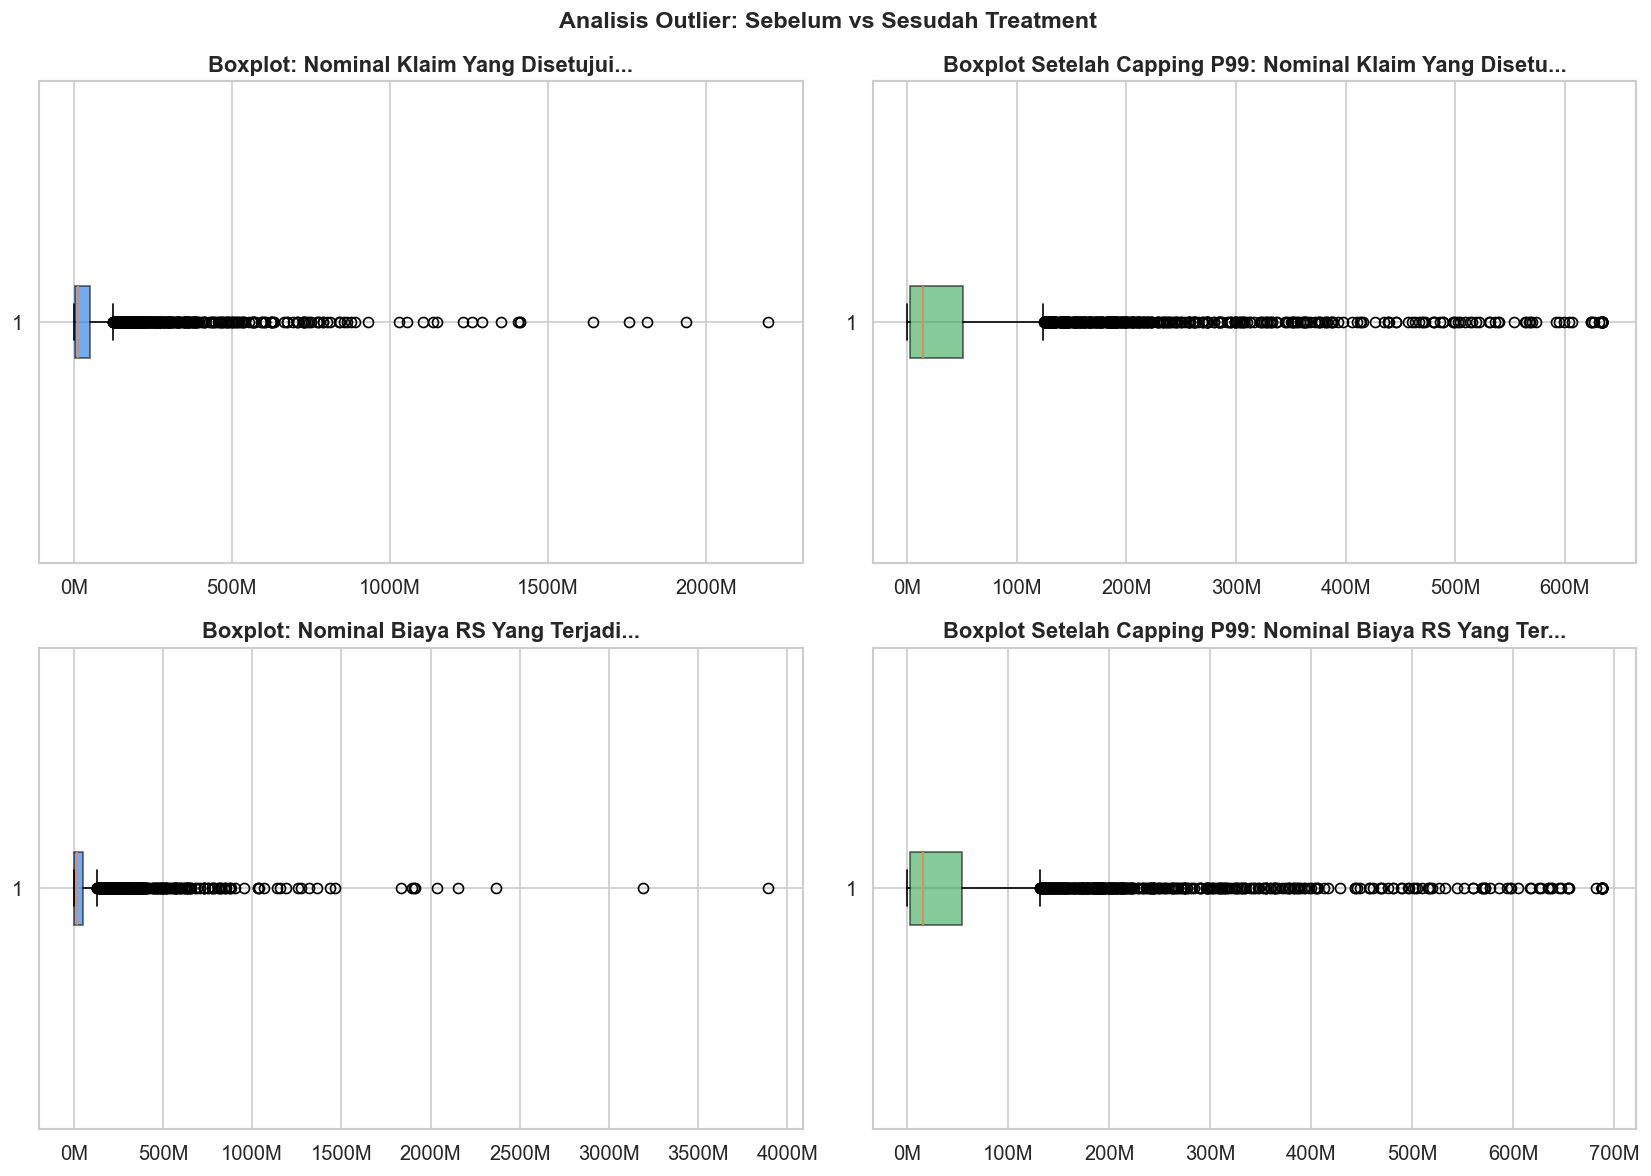


Ukuran data setelah penghapusan nilai negatif: 4,627 baris

✅ Outlier detection dan treatment selesai.


In [8]:
# ============================================================
# SEL 5: OUTLIER DETECTION DAN TREATMENT
# ============================================================

cost_cols = ['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']

def detect_outliers_iqr(series, multiplier=1.5):
    """
    Deteksi outlier menggunakan metode IQR (Interquartile Range).
    Outlier didefinisikan sebagai nilai di luar batas:
    [Q1 - multiplier*IQR, Q3 + multiplier*IQR]
    
    Parameter:
    - series     : Kolom data numerik (pd.Series)
    - multiplier : Pengali IQR. Default 1.5 (standar Tukey)
    
    Return:
    - Tuple berisi (lower_bound, upper_bound, mask_outlier)
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outlier_mask = (series < lower) | (series > upper)
    return lower, upper, outlier_mask


def detect_outliers_zscore(series, threshold=3.0):
    """
    Deteksi outlier menggunakan Z-Score.
    Nilai dengan |z| > threshold dikategorikan sebagai outlier.
    
    Parameter:
    - series    : Kolom data numerik (pd.Series)
    - threshold : Batas Z-Score. Default 3.0 (standar statistik)
    
    Return:
    - Tuple berisi (z_scores, mask_outlier)
    """
    z_scores = np.abs(stats.zscore(series.dropna()))
    # Reindex agar panjangnya sama dengan series asli
    z_full = pd.Series(index=series.index, dtype=float)
    z_full.loc[series.dropna().index] = z_scores
    outlier_mask = z_full > threshold
    return z_full, outlier_mask


print('ANALISIS OUTLIER PADA KOLOM BIAYA')
print('=' * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Outlier: Sebelum vs Sesudah Treatment', fontsize=14, fontweight='bold')

for i, col in enumerate(cost_cols):
    lower_iqr, upper_iqr, mask_iqr = detect_outliers_iqr(df[col])
    z_scores, mask_z = detect_outliers_zscore(df[col])
    
    # Gabungkan deteksi: outlier jika terdeteksi oleh KEDUA metode (konservatif)
    combined_mask = mask_iqr & mask_z.fillna(False)
    
    n_outliers = combined_mask.sum()
    pct_outliers = n_outliers / len(df) * 100
    
    print(f'\nKolom: {col}')
    print(f'  Batas IQR     : [{lower_iqr:,.0f} - {upper_iqr:,.0f}]')
    print(f'  Outlier IQR   : {mask_iqr.sum()} ({mask_iqr.sum()/len(df)*100:.2f}%)')
    print(f'  Outlier Z>3   : {mask_z.fillna(False).sum()} ({mask_z.fillna(False).sum()/len(df)*100:.2f}%)')
    print(f'  Outlier Konfirmasi (IQR+Z): {n_outliers} ({pct_outliers:.2f}%)')
    
    # --- Visualisasi Boxplot ---
    axes[i][0].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='#1a73e8', alpha=0.6))
    axes[i][0].set_title(f'Boxplot: {col[:30]}...', fontweight='bold')
    axes[i][0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    
    # --- Simpan flag outlier sebagai fitur baru ---
    # STRATEGI: Outlier tidak dihapus, melainkan diberi flag (0/1)
    # Ini adalah sinyal penting untuk model Isolation Forest nantinya
    df[f'Flag_Outlier_{i+1}'] = combined_mask.astype(int)

# Hapus nilai negatif yang tidak logis
invalid_negative = (df['Nominal Klaim Yang Disetujui'] < 0) | \
                   (df['Nominal Biaya RS Yang Terjadi'] < 0)
print(f'\nNilai negatif tidak logis: {invalid_negative.sum()} baris')
df = df[~invalid_negative].copy()

# Winsorizing (Capping) pada persentil 99 untuk mengurangi pengaruh ekstrem
# TETAPI tetap menyimpan nilai asli sebagai referensi
for col in cost_cols:
    cap_value = df[col].quantile(0.99)
    df[f'{col}_Capped'] = df[col].clip(upper=cap_value)

# Visualisasi setelah capping
for i, col in enumerate(cost_cols):
    axes[i][1].boxplot(df[f'{col}_Capped'].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='#34a853', alpha=0.6))
    axes[i][1].set_title(f'Boxplot Setelah Capping P99: {col[:25]}...', fontweight='bold')
    axes[i][1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

print(f'\nUkuran data setelah penghapusan nilai negatif: {df.shape[0]:,} baris')
print('\n✅ Outlier detection dan treatment selesai.')

---
## Sel 6: Advanced Feature Engineering

**Tujuan:** Menciptakan fitur-fitur baru yang secara teoritis memiliki relevansi tinggi terhadap pendeteksian anomali biaya dan perilaku klaim. Fitur-fitur ini adalah 'bahan bakar' utama untuk model Hybrid AI yang akan dibangun.

**Fitur yang Dibuat:**
- `Patient_Age`: Usia peserta saat klaim diajukan
- `Policy_Tenure_Days`: Masa aktif polis dalam hari
- `Treatment_Duration`: Lama rawat inap (hari)
- `Claim_Frequency`: Frekuensi klaim per peserta
- `Cost_Gap_Ratio`: Rasio selisih biaya RS vs klaim yang disetujui
- `Approval_Rate`: Persentase klaim yang disetujui vs biaya RS
- `Payment_Delay_Days`: Jeda waktu antara pasien pulang dan pembayaran klaim
- `ICD_Category`: Kategori penyakit level pertama dari kode ICD
- `Age_Group`: Kelompok usia peserta
- `Cost_Per_Day`: Biaya rata-rata per hari rawat

In [9]:
# ============================================================
# SEL 6: ADVANCED FEATURE ENGINEERING
# ============================================================

REFERENCE_DATE = pd.Timestamp('2024-12-31')  # Tanggal referensi untuk perhitungan usia

# --- FITUR 1: Patient_Age ---
# Usia pasien pada saat tanggal masuk RS (lebih akurat daripada usia saat ini)
df['Patient_Age'] = (
    (df['Tanggal Pasien Masuk RS'] - df['Tanggal Lahir']).dt.days / 365.25
).round(1)
# Tangani nilai tidak wajar (usia < 0 atau > 120)
df['Patient_Age'] = df['Patient_Age'].clip(lower=0, upper=120)
print(f'Patient_Age: min={df["Patient_Age"].min():.1f}, max={df["Patient_Age"].max():.1f}, mean={df["Patient_Age"].mean():.1f}')


# --- FITUR 2: Policy_Tenure_Days ---
# Masa aktif polis dari tanggal efektif hingga tanggal klaim masuk
# Peserta baru dengan tenure pendek yang mengajukan klaim besar adalah sinyal risiko
df['Policy_Tenure_Days'] = (
    df['Tanggal Pasien Masuk RS'] - df['Tanggal Efektif Polis']
).dt.days
df['Policy_Tenure_Days'] = df['Policy_Tenure_Days'].clip(lower=0)
print(f'Policy_Tenure_Days: min={df["Policy_Tenure_Days"].min()}, max={df["Policy_Tenure_Days"].max()}, mean={df["Policy_Tenure_Days"].mean():.1f}')


# --- FITUR 3: Treatment_Duration ---
# Lama rawat (hari) dari masuk hingga keluar RS
# Rawat inap yang terlalu lama untuk diagnosa ringan adalah anomali potensial
df['Treatment_Duration'] = (
    df['Tanggal Pasien Keluar RS'] - df['Tanggal Pasien Masuk RS']
).dt.days
# Rawat jalan (OP) harusnya 0 hari, rawat inap minimal 1 hari
df['Treatment_Duration'] = df['Treatment_Duration'].clip(lower=0)
print(f'Treatment_Duration: min={df["Treatment_Duration"].min()}, max={df["Treatment_Duration"].max()}, mean={df["Treatment_Duration"].mean():.2f}')


# --- FITUR 4: Claim_Frequency ---
# Jumlah total klaim per nomor polis dalam dataset ini
# Frekuensi klaim tinggi dapat menandakan pola penggunaan berlebihan
claim_freq_map = df.groupby('Nomor Polis')['Claim ID'].count()
df['Claim_Frequency'] = df['Nomor Polis'].map(claim_freq_map)
print(f'Claim_Frequency: min={df["Claim_Frequency"].min()}, max={df["Claim_Frequency"].max()}, mean={df["Claim_Frequency"].mean():.2f}')


# --- FITUR 5: Cost_Gap_Ratio ---
# Rasio perbedaan antara biaya RS yang terjadi dengan klaim yang disetujui
# Formula: (Biaya_RS - Klaim_Disetujui) / Biaya_RS
# Nilai positif besar: AXA membayar jauh lebih sedikit dari biaya RS (penolakan parsial)
# Nilai negatif: Klaim disetujui melebihi biaya RS (potensi fraud)
df['Cost_Gap_Ratio'] = (
    (df['Nominal Biaya RS Yang Terjadi'] - df['Nominal Klaim Yang Disetujui']) /
    df['Nominal Biaya RS Yang Terjadi'].replace(0, np.nan)
).fillna(0)
print(f'Cost_Gap_Ratio: min={df["Cost_Gap_Ratio"].min():.4f}, max={df["Cost_Gap_Ratio"].max():.4f}, mean={df["Cost_Gap_Ratio"].mean():.4f}')


# --- FITUR 6: Approval_Rate ---
# Persentase biaya RS yang disetujui AXA
# Formula: Klaim_Disetujui / Biaya_RS * 100
# Persetujuan > 100% (klaim melebihi biaya RS) adalah anomali keras
df['Approval_Rate'] = (
    df['Nominal Klaim Yang Disetujui'] /
    df['Nominal Biaya RS Yang Terjadi'].replace(0, np.nan)
).fillna(0) * 100
print(f'Approval_Rate: min={df["Approval_Rate"].min():.2f}%, max={df["Approval_Rate"].max():.2f}%, mean={df["Approval_Rate"].mean():.2f}%')


# --- FITUR 7: Payment_Delay_Days ---
# Jeda antara tanggal pasien keluar RS dan tanggal pembayaran klaim
# Penundaan sangat lama bisa menandakan masalah administrasi atau investigasi
df['Payment_Delay_Days'] = (
    df['Tanggal Pembayaran Klaim'] - df['Tanggal Pasien Keluar RS']
).dt.days
df['Payment_Delay_Days'] = df['Payment_Delay_Days'].clip(lower=0)
print(f'Payment_Delay_Days: min={df["Payment_Delay_Days"].min()}, max={df["Payment_Delay_Days"].max()}, mean={df["Payment_Delay_Days"].mean():.2f}')


# --- FITUR 8: ICD_Category ---
# Ekstrak kategori utama ICD-10 (huruf pertama dari kode ICD)
# A=Infeksi, C=Kanker, I=Kardiovaskular, Z=Screening, dll.
df['ICD_Category'] = df['ICD Diagnosis'].str[0].str.upper().fillna('Z')
print(f'ICD_Category: {df["ICD_Category"].value_counts().head(5).to_dict()}')


# --- FITUR 9: Age_Group ---
# Binning usia ke kelompok untuk menangkap pola non-linear
age_bins = [0, 17, 30, 45, 60, 120]
age_labels = ['Anak (<18)', 'Dewasa Muda (18-30)', 'Dewasa (31-45)', 'Paruh Baya (46-60)', 'Senior (>60)']
df['Age_Group'] = pd.cut(
    df['Patient_Age'],
    bins=age_bins,
    labels=age_labels,
    right=True
)
print(f'Age_Group distribution:\n{df["Age_Group"].value_counts().to_dict()}')


# --- FITUR 10: Cost_Per_Day ---
# Biaya per hari rawat. Untuk rawat jalan, Treatment_Duration = 0, jadi gunakan 1
# Biaya per hari sangat tinggi untuk diagnosis ringan adalah sinyal anomali
df['Cost_Per_Day'] = df['Nominal Biaya RS Yang Terjadi'] / (
    df['Treatment_Duration'].replace(0, 1)
)
print(f'Cost_Per_Day: min={df["Cost_Per_Day"].min():,.0f}, max={df["Cost_Per_Day"].max():,.0f}, mean={df["Cost_Per_Day"].mean():,.0f}')


# --- FITUR 11: Is_Overseas ---
# Flag apakah klaim dilakukan di luar Indonesia
domestic_keywords = ['JAKARTA', 'SURABAYA', 'BANDUNG', 'BALI', 'MEDAN', 'SEMARANG',
                     'INDONESIA', 'MAKASSAR', 'PALEMBANG', 'YOGYAKARTA']
df['Is_Overseas'] = (~df['Lokasi RS'].str.upper().str.contains(
    '|'.join(domestic_keywords), na=False)
).astype(int)
print(f'Is_Overseas: {df["Is_Overseas"].value_counts().to_dict()}')


print('\n--- Ringkasan Fitur Baru ---')
new_features = [
    'Patient_Age', 'Policy_Tenure_Days', 'Treatment_Duration', 'Claim_Frequency',
    'Cost_Gap_Ratio', 'Approval_Rate', 'Payment_Delay_Days', 'Cost_Per_Day', 'Is_Overseas'
]
display(df[new_features].describe())
print('\n✅ Advanced Feature Engineering selesai. 11 fitur baru berhasil dibuat.')

Patient_Age: min=6.8, max=90.3, mean=59.3
Policy_Tenure_Days: min=2200, max=4942, mean=3599.1
Treatment_Duration: min=0, max=54, mean=1.26
Claim_Frequency: min=1, max=222, mean=28.17
Cost_Gap_Ratio: min=-11671.2500, max=1.0000, mean=-3.0670
Approval_Rate: min=0.00%, max=1167225.00%, mean=406.65%
Payment_Delay_Days: min=0, max=606, mean=65.03
ICD_Category: {'C': 935, 'N': 713, 'H': 549, 'K': 543, 'I': 383}
Age_Group distribution:
{'Senior (>60)': 2281, 'Paruh Baya (46-60)': 1803, 'Dewasa (31-45)': 442, 'Dewasa Muda (18-30)': 65, 'Anak (<18)': 36}
Cost_Per_Day: min=0, max=855,059,315, mean=34,182,281
Is_Overseas: {0: 3109, 1: 1518}

--- Ringkasan Fitur Baru ---


,Patient_Age,Policy_Tenure_Days,Treatment_Duration,Claim_Frequency,Cost_Gap_Ratio,Approval_Rate,Payment_Delay_Days,Cost_Per_Day,Is_Overseas
count,"4,627.00","4,627.00","4,627.00","4,627.00","4,627.00","4,627.00","4,627.00","4,627.00","4,627.00"
mean,59.35,"3,599.08",1.26,28.17,-3.07,406.65,65.03,"34,182,281.14",0.33
std,12.57,639.47,2.93,55.52,176.95,"17,695.05",33.79,"71,608,927.70",0.47
min,6.80,"2,200.00",0.00,1.00,"-11,671.25",0.00,0.00,0.00,0.00
25%,51.40,"3,082.00",0.00,3.00,0.00,92.39,44.00,"2,624,900.00",0.00
50%,59.90,"3,591.00",0.00,6.00,0.01,98.83,61.00,"9,116,000.00",0.00
75%,68.95,"4,155.00",1.00,18.00,0.08,100.00,81.00,"32,859,066.59",1.00
max,90.30,"4,942.00",54.00,222.00,1.00,"1,167,225.00",606.00,"855,059,315.00",1.00



✅ Advanced Feature Engineering selesai. 11 fitur baru berhasil dibuat.


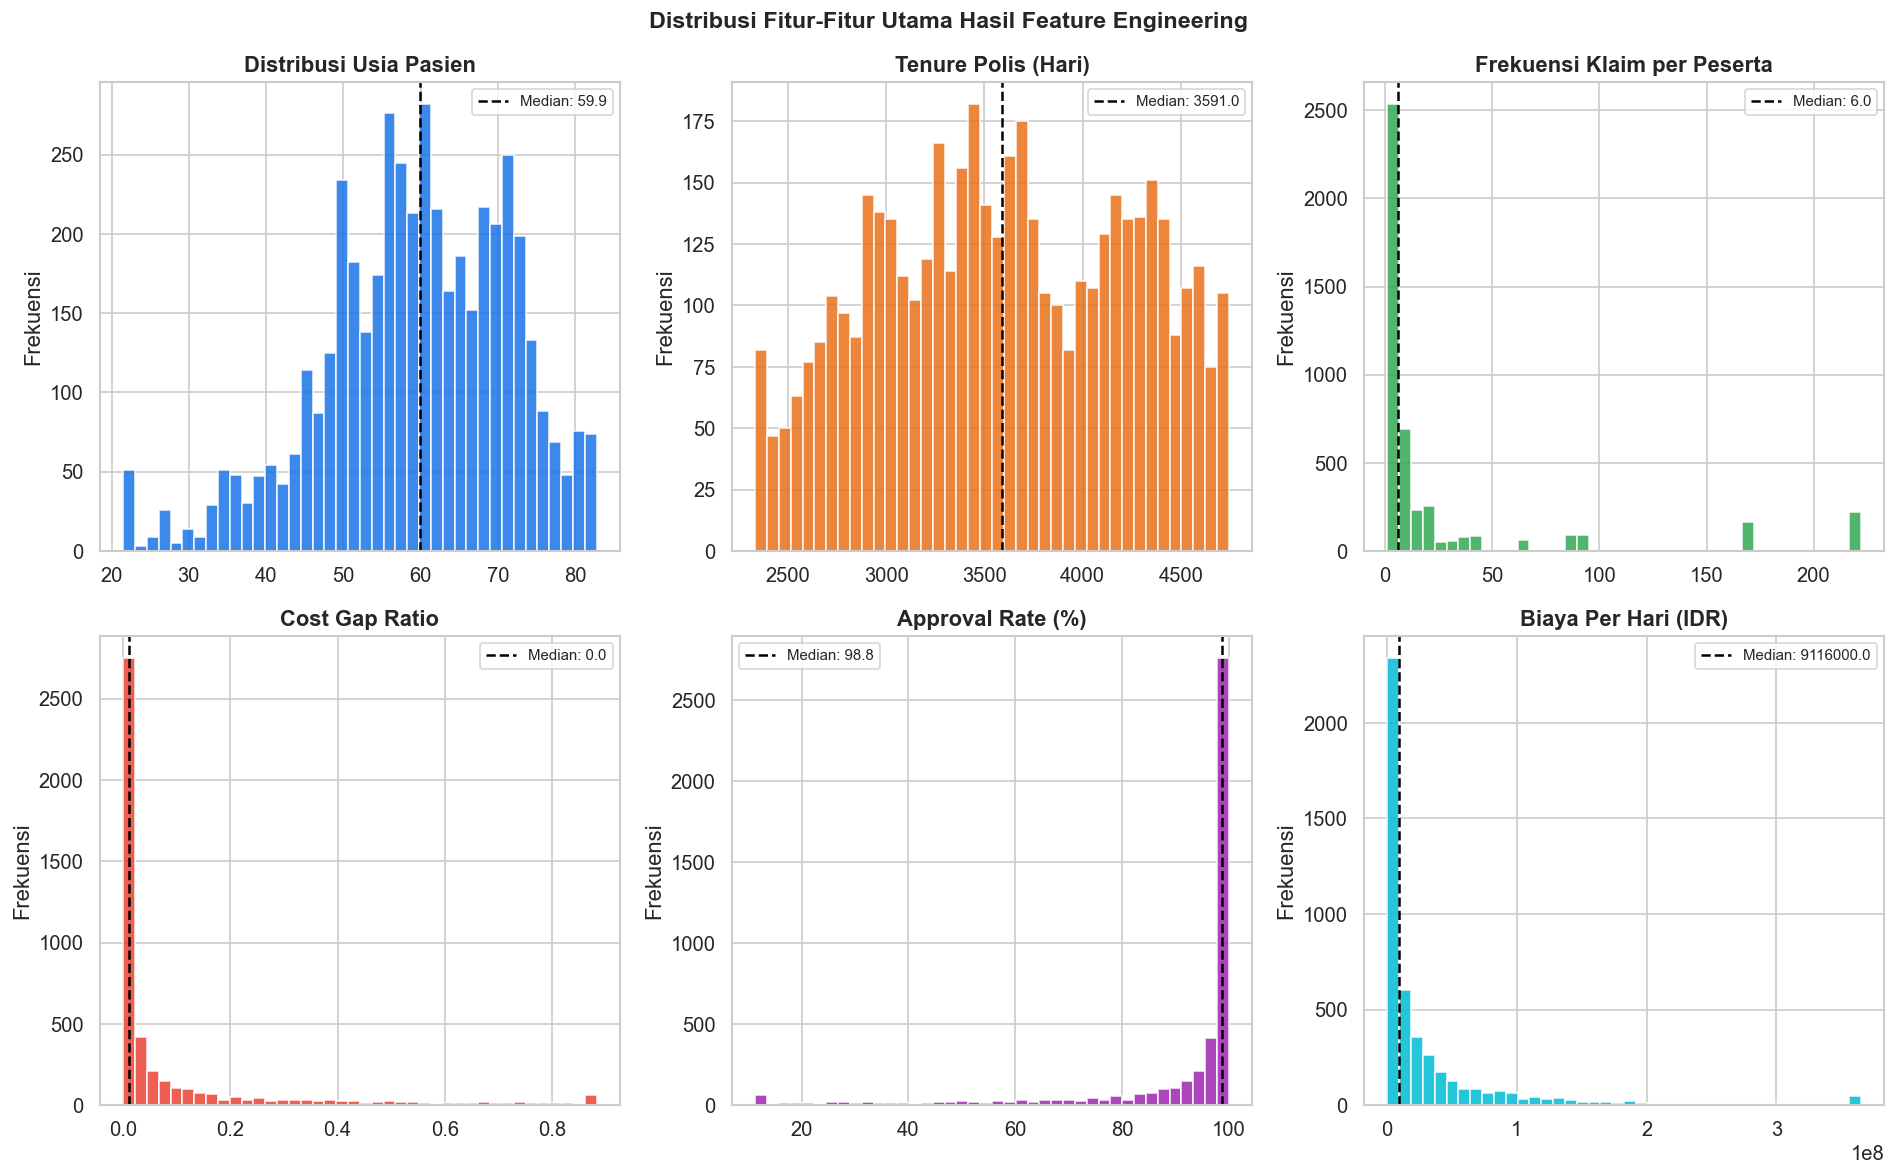

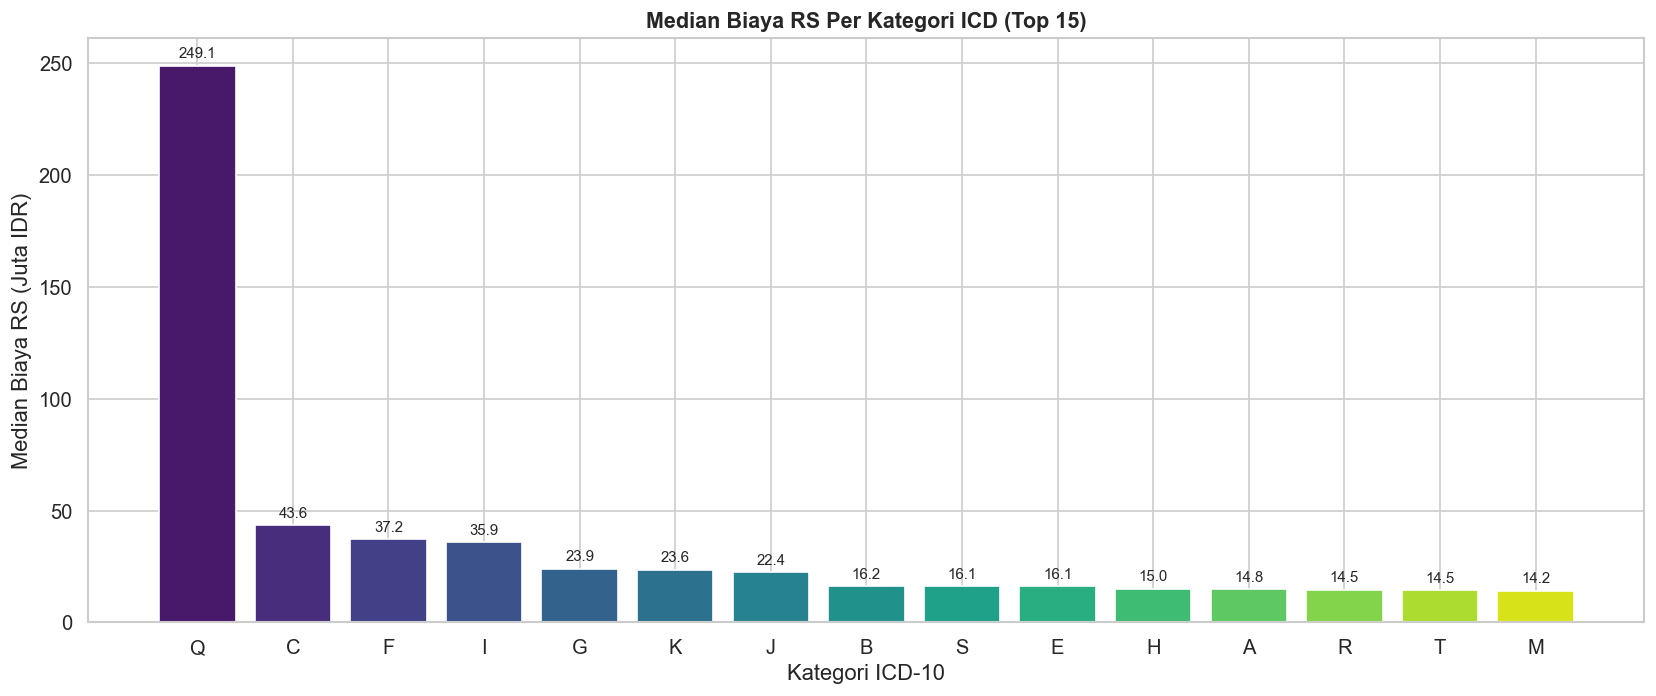

[INSIGHT] Kategori C (Kanker/Neoplasma) dan beberapa kategori lain memiliki median biaya tertinggi.
[INSIGHT] Ini konsisten dengan fakta bahwa klaim luar negeri (Singapore, Malaysia) dominan di dataset.


In [10]:
# ============================================================
# SEL 6B: VISUALISASI FITUR BARU
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Fitur-Fitur Utama Hasil Feature Engineering', fontsize=14, fontweight='bold')

plot_configs = [
    ('Patient_Age', 'Distribusi Usia Pasien', '#1a73e8'),
    ('Policy_Tenure_Days', 'Tenure Polis (Hari)', '#e8711a'),
    ('Claim_Frequency', 'Frekuensi Klaim per Peserta', '#34a853'),
    ('Cost_Gap_Ratio', 'Cost Gap Ratio', '#ea4335'),
    ('Approval_Rate', 'Approval Rate (%)', '#9c27b0'),
    ('Cost_Per_Day', 'Biaya Per Hari (IDR)', '#00bcd4'),
]

for idx, (col, title, color) in enumerate(plot_configs):
    ax = axes[idx // 3][idx % 3]
    data = df[col].dropna()
    # Clip extreme values untuk visualisasi yang lebih bersih
    data_viz = data.clip(lower=data.quantile(0.01), upper=data.quantile(0.99))
    ax.hist(data_viz, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Frekuensi')
    
    # Tambahkan garis median
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Visualisasi biaya per kategori ICD
fig, ax = plt.subplots(figsize=(14, 6))
icd_cost = df.groupby('ICD_Category')['Nominal Biaya RS Yang Terjadi'].median().sort_values(ascending=False).head(15)
bars = ax.bar(icd_cost.index, icd_cost.values / 1e6, color=sns.color_palette('viridis', len(icd_cost)))
ax.set_title('Median Biaya RS Per Kategori ICD (Top 15)', fontweight='bold', fontsize=13)
ax.set_xlabel('Kategori ICD-10')
ax.set_ylabel('Median Biaya RS (Juta IDR)')
ax.bar_label(bars, fmt='%.1f', fontsize=9, padding=3)
plt.tight_layout()
plt.show()

print('[INSIGHT] Kategori C (Kanker/Neoplasma) dan beberapa kategori lain memiliki median biaya tertinggi.')
print('[INSIGHT] Ini konsisten dengan fakta bahwa klaim luar negeri (Singapore, Malaysia) dominan di dataset.')

---
## Sel 7: Encoding dan Scaling

**Tujuan:** Mengubah fitur kategorikal menjadi representasi numerik agar dapat diproses oleh algoritma machine learning. Kemudian melakukan normalisasi/standardisasi pada fitur numerik.

**Strategi Encoding:**
- Label Encoding untuk fitur biner dan ordinal
- One-Hot Encoding untuk fitur nominal dengan kardinalitas rendah

**Strategi Scaling:**
- MinMaxScaler untuk fitur yang akan digunakan di K-Means (sensitif terhadap skala)
- StandardScaler untuk fitur yang akan digunakan di Regression (asumsi distribusi normal)

In [12]:
# ============================================================
# SEL 7: ENCODING DAN SCALING
# ============================================================

df_model = df.copy()

# -------------------------------------------------------
# ENCODING
# -------------------------------------------------------

print('PROSES ENCODING')
print('=' * 50)

# Label Encoding untuk fitur biner
le = LabelEncoder()

# Gender: M=1, F=0
df_model['Gender_Enc'] = le.fit_transform(df_model['Gender'])
print(f'Gender Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Reimburse/Cashless: R=1, C=0
df_model['Reimburse_Enc'] = (df_model['Reimburse/Cashless'] == 'R').astype(int)
print(f'Reimburse_Enc: R=1, C=0')

# Inpatient/Outpatient: IP=1, OP=0
df_model['InPatient_Enc'] = (df_model['Inpatient/Outpatient'] == 'IP').astype(int)
print(f'InPatient_Enc: IP=1, OP=0')

# Plan Code: Ordinal encoding berdasarkan coverage level
# Asumsi: M-001=1 (basic), M-002=2 (standard), M-003=3 (premium)
plan_map = {'M-001': 1, 'M-002': 2, 'M-003': 3}
df_model['Plan_Level'] = df_model['Plan Code'].map(plan_map).fillna(1).astype(int)
print(f'Plan_Level Encoding: {plan_map}')

# Age_Group: Ordinal encoding
age_group_map = {
    'Anak (<18)': 1,
    'Dewasa Muda (18-30)': 2,
    'Dewasa (31-45)': 3,
    'Paruh Baya (46-60)': 4,
    'Senior (>60)': 5
}
df_model['Age_Group_Enc'] = df_model['Age_Group'].map(age_group_map).fillna(3).astype(int)
print(f'Age_Group_Enc: {age_group_map}')

# ICD_Category: Label Encoding (kardinalitas sedang)
df_model['ICD_Category_Enc'] = le.fit_transform(df_model['ICD_Category'].astype(str))
print(f'ICD_Category_Enc: {len(df_model["ICD_Category"].unique())} kategori unik')

# One-Hot Encoding untuk Domisili (kardinalitas: 21 kota)
# Gunakan get_dummies dengan drop_first untuk menghindari multikolinearitas
domisili_dummies = pd.get_dummies(
    df_model['Domisili'],
    prefix='Domisili',
    drop_first=True
)
df_model = pd.concat([df_model, domisili_dummies], axis=1)
print(f'Domisili: {len(domisili_dummies.columns)} kolom dummy dibuat')


# -------------------------------------------------------
# DEFINISI FITUR FINAL UNTUK MODEL
# -------------------------------------------------------

# Fitur numerik yang akan di-scale
numeric_features = [
    'Patient_Age',
    'Policy_Tenure_Days',
    'Treatment_Duration',
    'Claim_Frequency',
    'Cost_Gap_Ratio',
    'Approval_Rate',
    'Payment_Delay_Days',
    'Cost_Per_Day',
    'Nominal Biaya RS Yang Terjadi',
    'Nominal Klaim Yang Disetujui',
]

encoded_features = [
    'Gender_Enc', 'Reimburse_Enc', 'InPatient_Enc',
    'Plan_Level', 'Age_Group_Enc', 'ICD_Category_Enc',
    'Is_Overseas'
]

domisili_features = [c for c in domisili_dummies.columns]

all_features = numeric_features + encoded_features + domisili_features

# -------------------------------------------------------
# SCALING
# -------------------------------------------------------

print('\nPROSES SCALING')
print('=' * 50)

# Bersihkan nilai inf yang mungkin muncul dari pembagian
df_model[numeric_features] = df_model[numeric_features].replace([np.inf, -np.inf], np.nan)
df_model[numeric_features] = df_model[numeric_features].fillna(df_model[numeric_features].median())

# MinMaxScaler: Normalisasi ke rentang [0,1]
# Cocok untuk K-Means dan Isolation Forest
scaler_minmax = MinMaxScaler()
numeric_scaled_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df_model[numeric_features]),
    columns=[f'{c}_MM' for c in numeric_features],
    index=df_model.index
)

# StandardScaler: Standardisasi ke mean=0, std=1
# Cocok untuk Regression dan perbandingan koefisien
scaler_std = StandardScaler()
numeric_scaled_std = pd.DataFrame(
    scaler_std.fit_transform(df_model[numeric_features]),
    columns=[f'{c}_STD' for c in numeric_features],
    index=df_model.index
)

# Gabungkan semua fitur scaled ke df_model
df_model = pd.concat([df_model, numeric_scaled_minmax, numeric_scaled_std], axis=1)

print(f'MinMaxScaler: {len(numeric_scaled_minmax.columns)} fitur dinormalisasi ke [0,1]')
print(f'StandardScaler: {len(numeric_scaled_std.columns)} fitur distandardisasi ke mean=0, std=1')
print('\n✅ Encoding dan Scaling selesai.')
print(f'Total dimensi dataset: {df_model.shape[0]:,} baris x {df_model.shape[1]} kolom')

PROSES ENCODING
Gender Encoding: {'F': np.int64(0), 'M': np.int64(1)}
Reimburse_Enc: R=1, C=0
InPatient_Enc: IP=1, OP=0
Plan_Level Encoding: {'M-001': 1, 'M-002': 2, 'M-003': 3}
Age_Group_Enc: {'Anak (<18)': 1, 'Dewasa Muda (18-30)': 2, 'Dewasa (31-45)': 3, 'Paruh Baya (46-60)': 4, 'Senior (>60)': 5}
ICD_Category_Enc: 20 kategori unik
Domisili: 19 kolom dummy dibuat

PROSES SCALING
MinMaxScaler: 10 fitur dinormalisasi ke [0,1]
StandardScaler: 10 fitur distandardisasi ke mean=0, std=1

✅ Encoding dan Scaling selesai.
Total dimensi dataset: 4,627 baris x 78 kolom


---
## Sel 8: Feature Selection dan Analisis Korelasi

**Tujuan:** Mengidentifikasi dan memilih fitur yang paling informatif terhadap target variabel (`Nominal Klaim Yang Disetujui`). Langkah ini mengurangi dimensionalitas, menghilangkan noise, dan mencegah overfitting.

**Metode yang Digunakan:**
1. Heatmap korelasi Pearson untuk visualisasi hubungan antar fitur
2. SelectKBest dengan F-Regression untuk pemilihan berbasis statistik
3. Mutual Information untuk menangkap hubungan non-linear

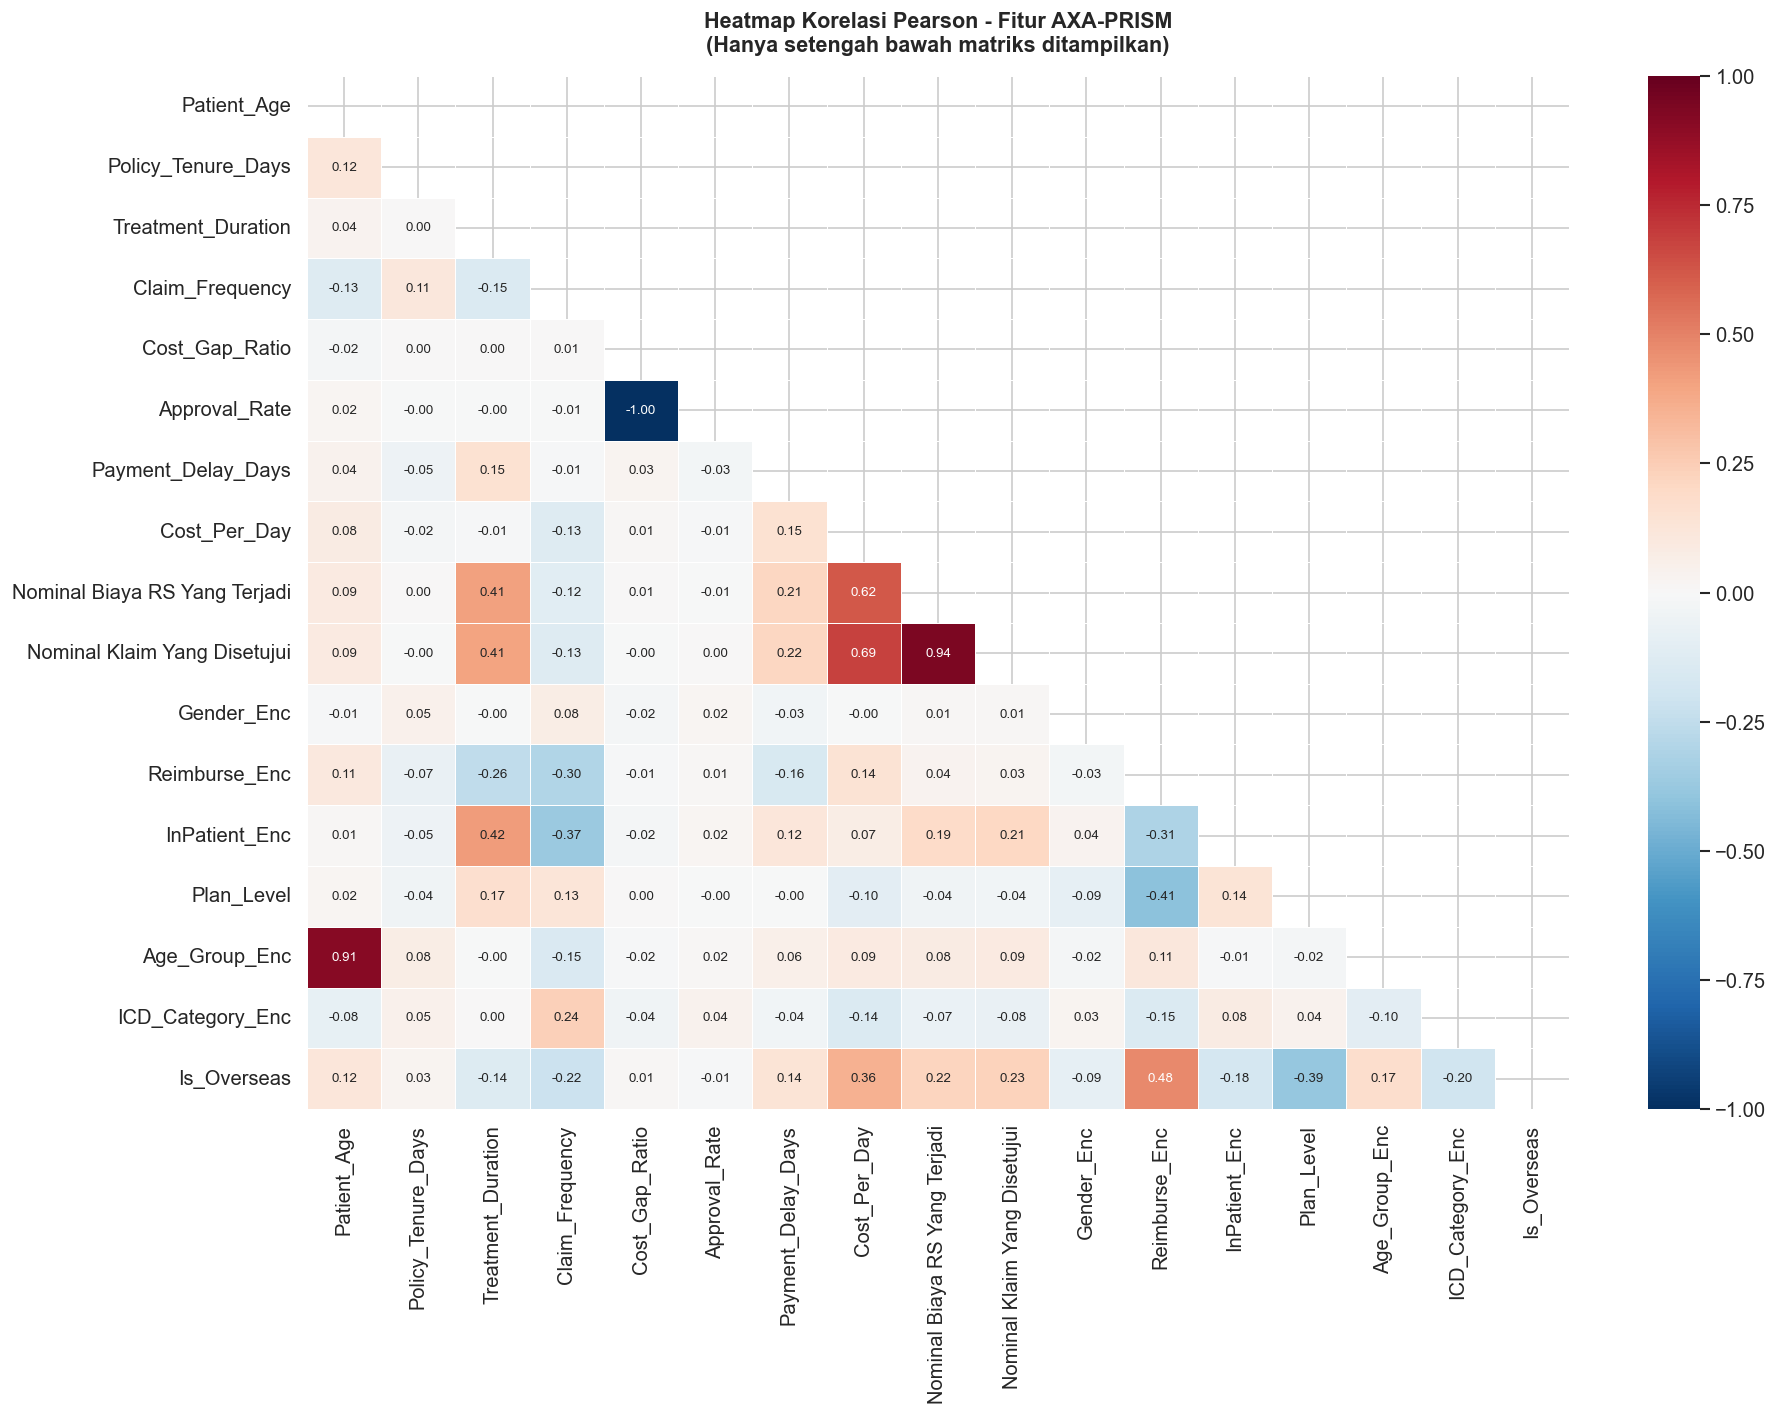


Korelasi Fitur terhadap Target Variable:


,Korelasi Absolut
Nominal Biaya RS Yang Terjadi,0.94
Cost_Per_Day,0.69
Treatment_Duration,0.41
Is_Overseas,0.23
Payment_Delay_Days,0.22
InPatient_Enc,0.21
Claim_Frequency,0.13
Patient_Age,0.09
Age_Group_Enc,0.09
ICD_Category_Enc,0.08


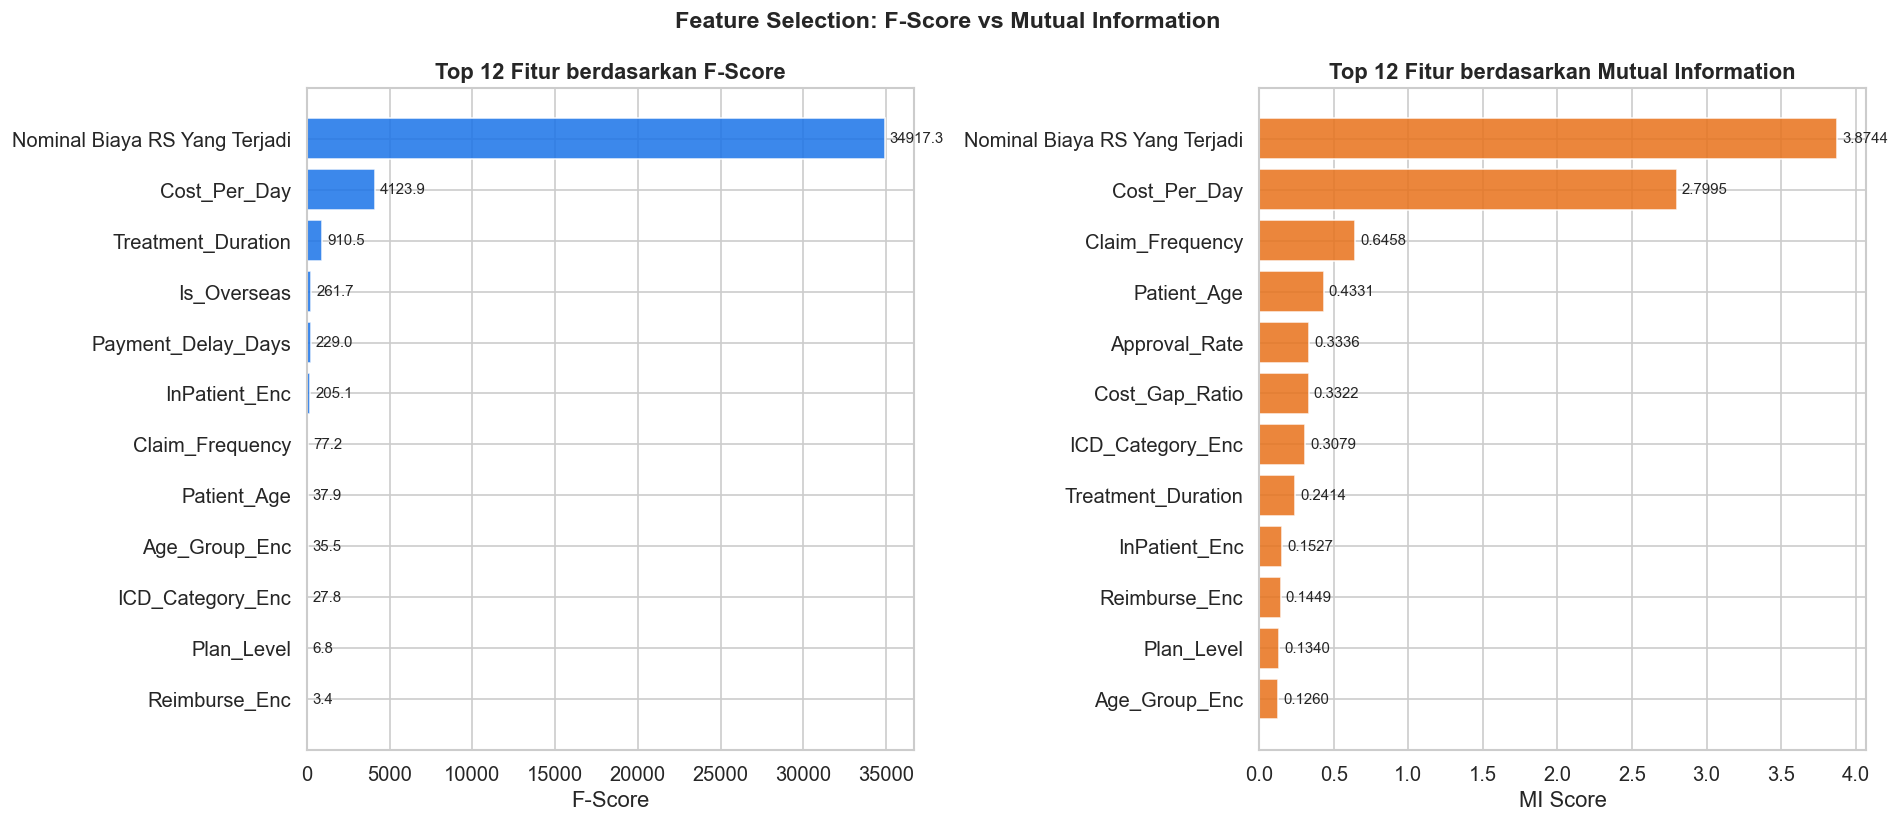


Total fitur terpilih: 14
Daftar fitur terpilih:
  - Age_Group_Enc
  - Approval_Rate
  - Claim_Frequency
  - Cost_Gap_Ratio
  - Cost_Per_Day
  - ICD_Category_Enc
  - InPatient_Enc
  - Is_Overseas
  - Nominal Biaya RS Yang Terjadi
  - Nominal Klaim Yang Disetujui
  - Patient_Age
  - Payment_Delay_Days
  - Reimburse_Enc
  - Treatment_Duration

✅ Feature Selection selesai.


In [13]:
# ============================================================
# SEL 8: FEATURE SELECTION DAN ANALISIS KORELASI
# ============================================================

# Target variabel untuk pemilihan fitur berbasis regresi
TARGET = 'Nominal Klaim Yang Disetujui'

# Fitur kandidat untuk analisis korelasi (numerik asli + encoded)
candidate_features = numeric_features + encoded_features

# -------------------------------------------------------
# HEATMAP KORELASI
# -------------------------------------------------------

corr_matrix = df_model[candidate_features].corr(method='pearson')

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title(
    'Heatmap Korelasi Pearson - Fitur AXA-PRISM\n(Hanya setengah bawah matriks ditampilkan)',
    fontweight='bold', fontsize=13, pad=15
)
plt.tight_layout()
plt.show()

# Tampilkan korelasi terhadap target (diurutkan)
print('\nKorelasi Fitur terhadap Target Variable:')
target_corr = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)
display(target_corr.to_frame('Korelasi Absolut'))


# -------------------------------------------------------
# SELEKSI FITUR DENGAN SELECTKBEST (F-REGRESSION)
# -------------------------------------------------------

# Siapkan matriks fitur X dan target y
feature_cols_for_selection = [f for f in candidate_features if f != TARGET]

X_sel = df_model[feature_cols_for_selection].fillna(0)
y_sel = df_model[TARGET].fillna(df_model[TARGET].median())

# F-Regression: menghitung statistik F antara setiap fitur dan target
k_best = min(15, len(feature_cols_for_selection))
selector_f = SelectKBest(score_func=f_regression, k=k_best)
selector_f.fit(X_sel, y_sel)

f_scores = pd.DataFrame({
    'Fitur': feature_cols_for_selection,
    'F-Score': selector_f.scores_,
    'P-Value': selector_f.pvalues_
}).sort_values('F-Score', ascending=False)

# Mutual Information: menangkap hubungan non-linear
mi_scores = mutual_info_regression(X_sel, y_sel, random_state=42)
mi_df = pd.DataFrame({
    'Fitur': feature_cols_for_selection,
    'MI-Score': mi_scores
}).sort_values('MI-Score', ascending=False)

# Visualisasi Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Selection: F-Score vs Mutual Information', fontsize=14, fontweight='bold')

top_n = 12
f_top = f_scores.head(top_n)
mi_top = mi_df.head(top_n)

# F-Score Bar Chart
bars1 = axes[0].barh(f_top['Fitur'][::-1], f_top['F-Score'][::-1],
                      color='#1a73e8', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Top {top_n} Fitur berdasarkan F-Score', fontweight='bold')
axes[0].set_xlabel('F-Score')
axes[0].bar_label(bars1, fmt='%.1f', padding=3, fontsize=9)

# Mutual Information Bar Chart
bars2 = axes[1].barh(mi_top['Fitur'][::-1], mi_top['MI-Score'][::-1],
                      color='#e8711a', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Top {top_n} Fitur berdasarkan Mutual Information', fontweight='bold')
axes[1].set_xlabel('MI Score')
axes[1].bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()


# -------------------------------------------------------
# FINALISASI FITUR TERPILIH
# -------------------------------------------------------
# Gabungkan insight dari kedua metode
# Ambil fitur yang muncul di Top-10 setidaknya satu metode

selected_by_f  = set(f_scores.head(10)['Fitur'])
selected_by_mi = set(mi_df.head(10)['Fitur'])
SELECTED_FEATURES = list(selected_by_f.union(selected_by_mi))

# Tambahkan fitur kunci yang wajib ada secara domain knowledge
must_have = [
    'Nominal Biaya RS Yang Terjadi', 'Nominal Klaim Yang Disetujui',
    'Cost_Gap_Ratio', 'Approval_Rate', 'Claim_Frequency',
    'Is_Overseas', 'InPatient_Enc'
]
SELECTED_FEATURES = list(set(SELECTED_FEATURES + must_have))

print(f'\nTotal fitur terpilih: {len(SELECTED_FEATURES)}')
print('Daftar fitur terpilih:')
for f in sorted(SELECTED_FEATURES):
    print(f'  - {f}')

print('\n✅ Feature Selection selesai.')

---
## Sel 9: Dataset Splitting

**Tujuan:** Membagi dataset menjadi set pelatihan (train) dan pengujian (test) dengan rasio 80:20. Stratifikasi tidak diperlukan di sini karena target adalah variabel kontinu (regression). Sebelum splitting, kita akan membuat variabel target turunan untuk keperluan model klasifikasi anomali.

In [14]:
# ============================================================
# SEL 9: DATASET SPLITTING
# ============================================================

# -------------------------------------------------------
# BUAT TARGET VARIABEL TURUNAN: Anomaly_Label
# Logika Dynamic Percentile Ranking:
# Klaim dikategorikan ANOMALI jika Cost_Gap_Ratio atau Approval_Rate
# melampaui threshold dinamis berdasarkan persentil distribusi.
# Pendekatan ini lebih adaptif dibanding hard threshold statis.
# -------------------------------------------------------

def create_anomaly_label_dynamic_percentile(df, percentile_threshold=90):
    """
    Membuat label anomali menggunakan Dynamic Percentile Ranking.
    
    Sebuah klaim diklasifikasikan sebagai anomali (1) jika memenuhi
    salah satu kondisi berikut:
    - Approval_Rate melampaui persentil ke-P (klaim melebihi biaya RS)
    - Cost_Per_Day melampaui persentil ke-P (biaya harian ekstrem)
    - Claim_Frequency melampaui persentil ke-P (penggunaan berlebihan)
    
    Pendekatan persentil memastikan ambang batas berkembang mengikuti
    distribusi data aktual, bukan nilai tetap yang bisa usang.
    
    Parameter:
    - df                  : DataFrame input
    - percentile_threshold : Nilai persentil sebagai ambang batas (default 90)
    
    Return:
    - pd.Series berisi label 0 (normal) atau 1 (anomali)
    """
    # Hitung threshold dinamis berbasis persentil distribusi aktual
    p_approval  = df['Approval_Rate'].quantile(percentile_threshold / 100)
    p_cost_day  = df['Cost_Per_Day'].quantile(percentile_threshold / 100)
    p_freq      = df['Claim_Frequency'].quantile(percentile_threshold / 100)
    
    print(f'  Threshold Dinamis (Persentil ke-{percentile_threshold}):')
    print(f'  - Approval_Rate  >= {p_approval:.2f}%')
    print(f'  - Cost_Per_Day   >= {p_cost_day:,.0f} IDR')
    print(f'  - Claim_Frequency >= {p_freq:.0f} klaim')
    
    # Labeling: anomali jika melampaui threshold di SALAH SATU dimensi
    anomaly_mask = (
        (df['Approval_Rate']   >= p_approval) |
        (df['Cost_Per_Day']    >= p_cost_day) |
        (df['Claim_Frequency'] >= p_freq)
    )
    return anomaly_mask.astype(int)


print('Membuat Anomaly Label dengan Dynamic Percentile Ranking (P90)...')
df_model['Anomaly_Label'] = create_anomaly_label_dynamic_percentile(df_model, percentile_threshold=90)

anomaly_dist = df_model['Anomaly_Label'].value_counts()
print(f'\nDistribusi Anomaly_Label:')
print(f'  Normal  (0): {anomaly_dist.get(0, 0):,} ({anomaly_dist.get(0,0)/len(df_model)*100:.1f}%)')
print(f'  Anomali (1): {anomaly_dist.get(1, 0):,} ({anomaly_dist.get(1,0)/len(df_model)*100:.1f}%)')


# -------------------------------------------------------
# DEFINISI FINAL FITUR MODEL
# -------------------------------------------------------

# Fitur yang sudah di-scale dengan MinMaxScaler untuk clustering/anomaly
MM_FEATURES = [f'{c}_MM' for c in numeric_features]

# Fitur yang sudah di-scale dengan StandardScaler untuk regression
STD_FEATURES = [f'{c}_STD' for c in numeric_features]

# Fitur gabungan untuk model lengkap
MODEL_FEATURES = MM_FEATURES + encoded_features

# Target untuk regression
TARGET_REG   = 'Nominal Klaim Yang Disetujui'

# Target untuk klasifikasi anomali
TARGET_CLASS = 'Anomaly_Label'


# -------------------------------------------------------
# SPLITTING
# -------------------------------------------------------

# Pastikan tidak ada NaN di fitur model
df_model[MODEL_FEATURES] = df_model[MODEL_FEATURES].fillna(0)

X = df_model[MODEL_FEATURES]
y_reg   = df_model[TARGET_REG].fillna(df_model[TARGET_REG].median())
y_class = df_model[TARGET_CLASS]

# Train-Test Split 80:20 dengan random_state untuk reproduktibilitas
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42
)

X_train_cls, X_test_cls, y_cls_train, y_cls_test = train_test_split(
    X, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class  # Stratifikasi untuk menjaga proporsi anomali
)

print('\n--- Hasil Dataset Splitting ---')
print(f'Total data  : {len(X):,} sampel')
print(f'Training    : {len(X_train):,} sampel ({len(X_train)/len(X)*100:.0f}%)')
print(f'Testing     : {len(X_test):,} sampel ({len(X_test)/len(X)*100:.0f}%)')
print(f'Jumlah Fitur: {X.shape[1]}')

print('\n✅ Dataset Splitting selesai.')

Membuat Anomaly Label dengan Dynamic Percentile Ranking (P90)...
  Threshold Dinamis (Persentil ke-90):
  - Approval_Rate  >= 100.00%
  - Cost_Per_Day   >= 89,824,660 IDR
  - Claim_Frequency >= 91 klaim

Distribusi Anomaly_Label:
  Normal  (0): 2,565 (55.4%)
  Anomali (1): 2,062 (44.6%)

--- Hasil Dataset Splitting ---
Total data  : 4,627 sampel
Training    : 3,701 sampel (80%)
Testing     : 926 sampel (20%)
Jumlah Fitur: 17

✅ Dataset Splitting selesai.


---
## Sel 10: Ekspor Data Final

**Tujuan:** Menyimpan dataset yang telah bersih, kaya fitur, dan siap model ke file `AXA_Prepared_Data.csv`. File ini merupakan output utama fase Data Preparation dan menjadi input untuk fase Modeling berikutnya dalam pipeline AXA-PRISM.

In [16]:
# ============================================================
# SEL 10: EKSPOR DATA FINAL
# ============================================================

# Kolom yang akan disimpan ke file output
# Kombinasi: ID, fitur asli penting, fitur engineered, fitur encoded, fitur scaled, dan target

EXPORT_COLUMNS = [
    # --- Identifier ---
    'Claim ID', 'Nomor Polis',
    
    # --- Informasi Polis ---
    'Plan Code', 'Plan_Level', 'Gender', 'Gender_Enc', 'Domisili',
    'Tanggal Lahir', 'Tanggal Efektif Polis',
    
    # --- Informasi Klaim ---
    'Reimburse/Cashless', 'Reimburse_Enc',
    'Inpatient/Outpatient', 'InPatient_Enc',
    'ICD Diagnosis', 'ICD Description', 'ICD_Category', 'ICD_Category_Enc',
    'Lokasi RS', 'Is_Overseas',
    'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS', 'Tanggal Pembayaran Klaim',
    
    # --- Biaya Asli ---
    'Nominal Biaya RS Yang Terjadi',
    'Nominal Klaim Yang Disetujui',
    
    # --- Fitur Engineered ---
    'Patient_Age', 'Age_Group', 'Age_Group_Enc',
    'Policy_Tenure_Days',
    'Treatment_Duration',
    'Claim_Frequency',
    'Cost_Gap_Ratio',
    'Approval_Rate',
    'Payment_Delay_Days',
    'Cost_Per_Day',
    
    # --- Flag Outlier ---
    'Flag_Outlier_1', 'Flag_Outlier_2',
    
    # --- Fitur Scaled (MinMax) ---
    'Patient_Age_MM', 'Policy_Tenure_Days_MM', 'Treatment_Duration_MM',
    'Claim_Frequency_MM', 'Cost_Gap_Ratio_MM', 'Approval_Rate_MM',
    'Payment_Delay_Days_MM', 'Cost_Per_Day_MM',
    'Nominal Biaya RS Yang Terjadi_MM', 'Nominal Klaim Yang Disetujui_MM',
    
    # --- Fitur Scaled (Standard) ---
    'Patient_Age_STD', 'Policy_Tenure_Days_STD', 'Treatment_Duration_STD',
    'Claim_Frequency_STD', 'Cost_Gap_Ratio_STD', 'Approval_Rate_STD',
    'Payment_Delay_Days_STD', 'Cost_Per_Day_STD',
    'Nominal Biaya RS Yang Terjadi_STD', 'Nominal Klaim Yang Disetujui_STD',
    
    # --- Target Variabel ---
    'Anomaly_Label',
]

# Filter kolom yang benar-benar tersedia di df_model
export_cols_valid = [c for c in EXPORT_COLUMNS if c in df_model.columns]
missing_cols = [c for c in EXPORT_COLUMNS if c not in df_model.columns]

if missing_cols:
    print(f'Kolom tidak tersedia (dilewati): {missing_cols}')

df_final = df_model[export_cols_valid].copy()

# Simpan ke CSV
output_path = 'AXA_Prepared_Data.csv'
df_final.to_csv(output_path, index=False)

print('=' * 60)
print('EKSPOR DATA SELESAI')
print('=' * 60)
print(f'  File          : {output_path}')
print(f'  Dimensi       : {df_final.shape[0]:,} baris x {df_final.shape[1]} kolom')
print(f'  Ukuran File   : ~{df_final.memory_usage(deep=True).sum() / 1024**2:.1f} MB (in-memory)')

print('\n--- Ringkasan Kolom yang Diekspor ---')
col_summary = pd.DataFrame({
    'Kolom': df_final.columns,
    'Tipe Data': df_final.dtypes.values,
    'Null': df_final.isnull().sum().values,
    'Contoh Nilai': [str(df_final[c].iloc[0])[:30] for c in df_final.columns]
})
display(col_summary)

print()
print('=' * 60)
print('RINGKASAN AKHIR PIPELINE DATA PREPARATION')
print('=' * 60)
print(f'  Raw Data (Polis)       : {df_polis.shape[0]:,} baris')
print(f'  Raw Data (Klaim)       : {df_klaim.shape[0]:,} baris')
print(f'  Data Setelah Merge     : {df.shape[0]:,} baris')
print(f'  Data Final (Prepared)  : {df_final.shape[0]:,} baris')
print(f'  Fitur Asli             : {df_polis.shape[1] + df_klaim.shape[1]} fitur')
print(f'  Fitur Setelah Engineering : {df_final.shape[1]} fitur')
print(f'  Training Set           : {len(X_train):,} sampel')
print(f'  Testing Set            : {len(X_test):,} sampel')
print(f'  Proporsi Anomali       : {df_final["Anomaly_Label"].mean()*100:.1f}%')
print('\n✅ Pipeline Data Preparation AXA-PRISM berhasil diselesaikan.')
print('   Data siap masuk ke Fase Modeling: Isolation Forest, K-Means, dan Regression.')

EKSPOR DATA SELESAI
  File          : AXA_Prepared_Data.csv
  Dimensi       : 4,627 baris x 57 kolom
  Ukuran File   : ~4.3 MB (in-memory)

--- Ringkasan Kolom yang Diekspor ---


,Kolom,Tipe Data,Null,Contoh Nilai
0,Claim ID,object,0,C-0001-M
1,Nomor Polis,object,0,POL-0176
2,Plan Code,object,0,M-001
3,Plan_Level,int64,0,1
4,Gender,object,0,F
5,Gender_Enc,int64,0,0
6,Domisili,object,0,JAKARTA
7,Tanggal Lahir,datetime64[ns],0,1967-02-20 00:00:00
8,Tanggal Efektif Polis,datetime64[ns],0,2015-01-09 00:00:00
9,Reimburse/Cashless,object,0,R



RINGKASAN AKHIR PIPELINE DATA PREPARATION
  Raw Data (Polis)       : 4,096 baris
  Raw Data (Klaim)       : 4,627 baris
  Data Setelah Merge     : 4,627 baris
  Data Final (Prepared)  : 4,627 baris
  Fitur Asli             : 19 fitur
  Fitur Setelah Engineering : 57 fitur
  Training Set           : 3,701 sampel
  Testing Set            : 926 sampel
  Proporsi Anomali       : 44.6%

✅ Pipeline Data Preparation AXA-PRISM berhasil diselesaikan.
   Data siap masuk ke Fase Modeling: Isolation Forest, K-Means, dan Regression.


---
## Ringkasan Keputusan Teknis dan Insight Data

**1. Outlier Treatment: Flag, Bukan Hapus**
Outlier pada data biaya klaim tidak dihapus, melainkan diberi flag biner. Ini karena dalam konteks fraud dan anomali asuransi, nilai ekstrem justru merupakan sinyal terkuat. Penghapusan outlier akan menghilangkan bukti kunci yang dibutuhkan model Isolation Forest.

**2. Winsorizing pada Persentil ke-99**
Capping dilakukan untuk menciptakan versi 'bersih' dari fitur biaya yang digunakan sebagai input model regresi. Model regresi sensitif terhadap nilai ekstrem yang dapat mendistorsi estimasi koefisien.

**3. Dynamic Percentile Labeling**
Anomaly_Label dibuat menggunakan threshold berbasis persentil distribusi aktual data, bukan nilai statis. Ini memastikan definisi 'anomali' selalu relevan dengan kondisi portofolio saat itu dan tidak membutuhkan kalibrasi ulang manual.

**4. Dual Scaler Strategy**
MinMaxScaler digunakan untuk K-Means dan Isolation Forest (algoritma berbasis jarak dan rentang), sedangkan StandardScaler digunakan untuk regresi (algoritma berbasis asumsi normalitas distribusi fitur).

**5. Konsolidasi ODC/ODS ke OP**
One Day Care dan One Day Surgery memiliki karakteristik klaim yang lebih mirip rawat jalan, sehingga dikonsolidasi untuk menyederhanakan model tanpa kehilangan informasi material.

### Insight Data:
- Distribusi biaya klaim bersifat *heavily right-skewed*, menandakan mayoritas klaim bernilai kecil dengan sebagian kecil klaim bernilai sangat besar.
- Klaim luar negeri (Singapore, Malaysia) mendominasi nilai klaim tertinggi, mengindikasikan potensi risiko konsentrasi pada polis dengan manfaat perawatan internasional.
- Kategori ICD C (Kanker/Neoplasma) secara konsisten memiliki biaya median tertinggi, yang merupakan pendorong utama kenaikan Loss Ratio AXA.

---
*Notebook ini merupakan bagian dari proyek AXA-PRISM. Fase berikutnya adalah Modeling: Isolation Forest untuk anomali, K-Means untuk segmentasi risiko, dan Regression untuk prediksi biaya.*